In [ ]:
%matplotlib inline


# Left ventricle bullseye

This example demonstrates how to create the 17 segment model for the left
ventricle recommended by the American Heart Association (AHA).


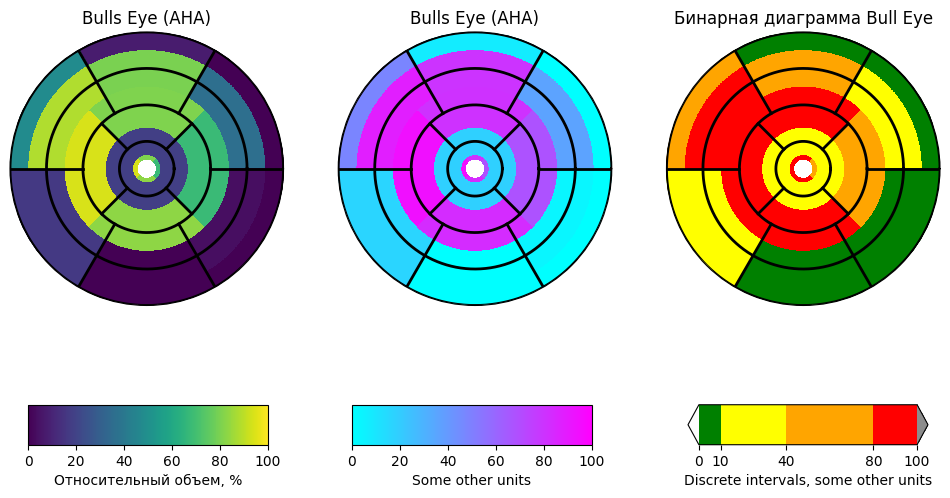

In [99]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


def bullseye_plot(ax, data, seg_bold=None, cmap=None, norm=None):
    """
    Bullseye representation for the left ventricle.

    Parameters
    ----------
    ax : axes
    data : list of int and float
        The intensity values for each of the 17 segments
    seg_bold : list of int, optional
        A list with the segments to highlight
    cmap : ColorMap or None, optional
        Optional argument to set the desired colormap
    norm : Normalize or None, optional
        Optional argument to normalize data into the [0.0, 1.0] range

    Notes
    -----
    This function creates the 17 segment model for the left ventricle according
    to the American Heart Association (AHA) [1]_

    References
    ----------
    .. [1] M. D. Cerqueira, N. J. Weissman, V. Dilsizian, A. K. Jacobs,
        S. Kaul, W. K. Laskey, D. J. Pennell, J. A. Rumberger, T. Ryan,
        and M. S. Verani, "Standardized myocardial segmentation and
        nomenclature for tomographic imaging of the heart",
        Circulation, vol. 105, no. 4, pp. 539-542, 2002.
    """
    if seg_bold is None:
        seg_bold = []

    linewidth = 2
    data = np.ravel(data)

    if cmap is None:
        cmap = plt.cm.viridis

    if norm is None:
        norm = mpl.colors.Normalize(vmin=data.min(), vmax=data.max())

    theta = np.linspace(0, 2 * np.pi, 768)
    r = np.linspace(0.2, 1, 4)

    # Remove grid
    ax.grid(False)

    # Create the bound for the segment 17
    for i in range(r.shape[0]):
        ax.plot(theta, np.repeat(r[i], theta.shape), '-k', lw=linewidth)

    # Create the bounds for the segments 1-12
    for i in range(6):
        theta_i = np.deg2rad(i * 60)
        ax.plot([theta_i, theta_i], [r[1], 1], '-k', lw=linewidth)

    # Create the bounds for the segments 13-16
    for i in range(4):
        theta_i = np.deg2rad(i * 90 - 45)
        ax.plot([theta_i, theta_i], [r[0], r[1]], '-k', lw=linewidth)

    # Fill the segments 1-6
    r0 = r[2:4]
    r0 = np.repeat(r0[:, np.newaxis], 128, axis=1).T
    for i in range(6):
        # First segment start at 60 degrees
        theta0 = theta[i * 128:i * 128 + 128] + np.deg2rad(60)
        theta0 = np.repeat(theta0[:, np.newaxis], 2, axis=1)
        z = np.ones((128, 2)) * data[i]
        ax.pcolormesh(theta0, r0, z, cmap=cmap, norm=norm, shading='auto')
        if i + 1 in seg_bold:
            ax.plot(theta0, r0, '-k', lw=linewidth + 2)
            ax.plot(theta0[0], [r[2], r[3]], '-k', lw=linewidth + 1)
            ax.plot(theta0[-1], [r[2], r[3]], '-k', lw=linewidth + 1)

    # Fill the segments 7-12
    r0 = r[1:3]
    r0 = np.repeat(r0[:, np.newaxis], 128, axis=1).T
    for i in range(6):
        # First segment start at 60 degrees
        theta0 = theta[i * 128:i * 128 + 128] + np.deg2rad(60)
        theta0 = np.repeat(theta0[:, np.newaxis], 2, axis=1)
        z = np.ones((128, 2)) * data[i + 6]
        ax.pcolormesh(theta0, r0, z, cmap=cmap, norm=norm, shading='auto')
        if i + 7 in seg_bold:
            ax.plot(theta0, r0, '-k', lw=linewidth + 2)
            ax.plot(theta0[0], [r[1], r[2]], '-k', lw=linewidth + 1)
            ax.plot(theta0[-1], [r[1], r[2]], '-k', lw=linewidth + 1)

    # Fill the segments 13-16
    r0 = r[0:2]
    r0 = np.repeat(r0[:, np.newaxis], 192, axis=1).T
    for i in range(4):
        # First segment start at 45 degrees
        theta0 = theta[i * 192:i * 192 + 192] + np.deg2rad(45)
        theta0 = np.repeat(theta0[:, np.newaxis], 2, axis=1)
        z = np.ones((192, 2)) * data[i + 12]
        ax.pcolormesh(theta0, r0, z, cmap=cmap, norm=norm, shading='auto')
        if i + 13 in seg_bold:
            ax.plot(theta0, r0, '-k', lw=linewidth + 2)
            ax.plot(theta0[0], [r[0], r[1]], '-k', lw=linewidth + 1)
            ax.plot(theta0[-1], [r[0], r[1]], '-k', lw=linewidth + 1)

    # Fill the segments 17
    if data.size == 17:
        r0 = np.array([0, r[0]])
        r0 = np.repeat(r0[:, np.newaxis], theta.size, axis=1).T
        theta0 = np.repeat(theta[:, np.newaxis], 2, axis=1)
        z = np.ones((theta.size, 2)) * data[16]
        ax.pcolormesh(theta0, r0, z, cmap=cmap, norm=norm, shading='auto')
        if 17 in seg_bold:
            ax.plot(theta0, r0, '-k', lw=linewidth + 2)

    ax.set_ylim([0, 1])
    ax.set_yticklabels([])
    ax.set_xticklabels([])


# Create the fake data
# data = np.arange(17) + 1

        #1    2.     3.   4.   5.   6.    7.   8.    9.    10.  11.  12.   13.   14.   15.   16.   17
data = [7.7, 47.7, 16.5, 0.0, 0.0, 0.0, 79.8, 88.0, 16.7, 0.0, 3.7, 36.2, 80.6, 94.0, 83.1, 67.9, 18.5]
# print(data)

# Make a figure and axes with dimensions as desired.
fig, ax = plt.subplots(figsize=(12, 8), nrows=1, ncols=3,
                       subplot_kw=dict(projection='polar'))
fig.canvas.manager.set_window_title('Left Ventricle Bulls Eyes (AHA)')

# Create the axis for the colorbars
axl = fig.add_axes([0.14, 0.15, 0.2, 0.05])
axl2 = fig.add_axes([0.41, 0.15, 0.2, 0.05])
axl3 = fig.add_axes([0.69, 0.15, 0.2, 0.05])


# Set the colormap and norm to correspond to the data for which
# the colorbar will be used.
cmap = mpl.cm.viridis
norm = mpl.colors.Normalize(vmin=0, vmax=100)
# Create an empty ScalarMappable to set the colorbar's colormap and norm.
# The following gives a basic continuous colorbar with ticks and labels.
fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap, norm=norm),
             cax=axl, orientation='horizontal', label='Относительный объем, %')


# And again for the second colorbar.
cmap2 = mpl.cm.cool
norm2 = mpl.colors.Normalize(vmin=0, vmax=100)
fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap2, norm=norm2),
             cax=axl2, orientation='horizontal', label='Some other units')


# The second example illustrates the use of a ListedColormap, a
# BoundaryNorm, and extended ends to show the "over" and "under"
# value colors.
cmap3 = (mpl.colors.ListedColormap(['g', 'yellow', 'orange', 'r'])
         .with_extremes(over='0.55', under='0.99'))
# If a ListedColormap is used, the length of the bounds array must be
# one greater than the length of the color list.  The bounds must be
# monotonically increasing.
bounds = [0, 10, 40, 80, 100]
norm3 = mpl.colors.BoundaryNorm(bounds, cmap3.N)
fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap3, norm=norm3),
             cax=axl3,
             extend='both',
             ticks=bounds,  # optional
             spacing='proportional',
             orientation='horizontal',
             label='Discrete intervals, some other units')


# Create the 17 segment model
bullseye_plot(ax[0], data, cmap=cmap, norm=norm)
ax[0].set_title('Bulls Eye (AHA)')

bullseye_plot(ax[1], data, cmap=cmap2, norm=norm2)
ax[1].set_title('Bulls Eye (AHA)')

# bullseye_plot(ax[2], data, seg_bold=[2, 3, 8, 9, 14, 17],
#               cmap=cmap3, norm=norm3)
# ax[2].set_title('Segments [2, 3, 8, 9, 14, 17] in bold')

bullseye_plot(ax[2], data, seg_bold=[],
              cmap=cmap3, norm=norm3)
ax[2].set_title('Бинарная диаграмма Bull Eye')



plt.show()